In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from sklearn.manifold import TSNE
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import kurtosis, skew
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.distance import cdist

# RQ2: Can E-E ratio identify distinct exploration-exploitation dynamics during early and late phases of motor learning, capturing rehabilitation progress over motor training?

In [2]:
# --- Load Data ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from pathlib import Path

# Paths (adjust if needed)
ucpmp_data_path = '../../saved_models/STCRL_transfer_learning/embeddings/embedded_trajectories_ucpmp.csv'
msl_data_path = '../../saved_models/STCRL_transfer_learning/embeddings/embedded_trajectories_msl.csv'

ucpmp_df = pd.read_csv(ucpmp_data_path)
msl_df = pd.read_csv(msl_data_path)

# Standardize column names for E–E ratio and group
MICRO_COL = 'exploration_exploitation_ratio'


In [3]:
save_path = "../plots/comparison/RQ2/"

In [4]:
msl_pid = pd.read_csv('../../Dataset/SMT_Dataset/preprocessed_human_smt_dataset.csv')
msl_pid

,participant_id,session_no,task_type,trial_no,day,block,start_point_x,start_point_y,target_point_x,target_point_y,...,time_diff_ms,Age,Cohort,Gestational_Age,mabc_total_test_score,mabc_standard_score,mabc_percentile,distances,rmsd,normalized_trajectory
0,MTRLRN002,1,0,1,Day-1,Block-1,0,0,451.220748,-453.255370,...,"[16, 31, 45, 62, 76, 91, 106, 136, 137, 166, 1...",5,Preterm,33.0,79,10,50.0,[630.49169002 621.50505278 612.7228091 604.15...,110.541539,[[ 0.00000000e+00 0.00000000e+00 1.60000000e...
1,MTRLRN002,1,0,2,Day-1,Block-1,0,0,-523.109406,-447.873534,...,"[1, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, ...",5,Preterm,33.0,79,10,50.0,[682.05597088 675.4999193 668.9795427 662.49...,304.594913,[[ 0.00000000e+00 0.00000000e+00 1.00000000e...
2,MTRLRN002,1,0,3,Day-1,Block-1,0,0,557.574475,325.309867,...,"[0, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, ...",5,Preterm,33.0,79,10,50.0,[645.53528595 645.53528595 645.53528595 645.53...,132.644564,[[ 0.00000000e+00 0.00000000e+00 0.00000000e...
3,MTRLRN002,1,0,4,Day-1,Block-1,0,0,476.961663,216.321327,...,"[1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 3, 3, ...",5,Preterm,33.0,79,10,50.0,[ 517.11764079 510.62061574 504.23767571 49...,462.858263,[[ 0.00000000e+00 0.00000000e+00 1.00000000e...
4,MTRLRN002,1,0,5,Day-1,Block-1,0,0,-497.485877,-249.059722,...,"[0, 0, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, ...",5,Preterm,33.0,79,10,50.0,[548.60482324 540.93551793 533.34320676 525.83...,364.397944,[[ 0.00000000e+00 0.00000000e+00 0.00000000e...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16315,MTRLRN079,5,1,20,Day-3,Block-1,0,0,332.677025,-235.033037,...,"[12, 21, 33, 41, 51, 65, 71, 83, 91, 101, 111,...",8,Term,40.0,35,2,0.5,[405.89604257 404.46647187 403.03736672 ... 30...,220.500581,[[ 0.00000000e+00 0.00000000e+00 1.20000000e...
16316,MTRLRN079,5,1,21,Day-3,Block-1,0,0,-541.816202,-203.887310,...,"[12, 20, 33, 40, 51, 61, 70, 83, 91, 101, 111,...",8,Term,40.0,35,2,0.5,[582.47960403 585.99988001 589.52453666 592.88...,54.671025,[[ 0.00000000e+00 0.00000000e+00 1.20000000e...
16317,MTRLRN079,5,1,22,Day-3,Block-1,0,0,-534.191589,326.568198,...,"[37, 41, 51, 61, 71, 84, 91, 101, 111, 121, 13...",8,Term,40.0,35,2,0.5,[627.17523828 628.25034819 629.33028672 630.41...,151.594559,[[ 0.00000000e+00 0.00000000e+00 3.70000000e...
16318,MTRLRN079,5,1,23,Day-3,Block-1,0,0,559.127069,355.643316,...,"[28, 31, 42, 53, 62, 75, 81, 91, 103, 112, 121...",8,Term,40.0,35,2,0.5,[ 664.12568906 665.60456108 667.08677801 66...,362.868256,[[ 0.00000000e+00 0.00000000e+00 2.80000000e...


In [5]:
msl_df['participant_id'] = msl_pid['participant_id']
msl_df.head()

,participant_id,session_no,task_type,trial_no,day,block,start_point_x,start_point_y,target_point_x,target_point_y,...,exploration_score,exploitation_score,novelty,avg_similarity_to_window,max_similarity_to_window,trial_seq,task_label,exploration_exploitation_ratio,learning_rate,strategy_stability
0,MTRLRN002,1,0,1,Day-1,Block-1,0,0,451.220748,-453.255370,...,0.048183,0.000000,1.000000,0.000000,0.000000,1.0,Unimanual,4.818315,NaN,NaN
1,MTRLRN002,1,0,2,Day-1,Block-1,0,0,-523.109406,-447.873534,...,0.233841,0.170576,4.865830,0.170479,0.170479,2.0,Unimanual,1.294971,NaN,NaN
2,MTRLRN002,1,0,3,Day-1,Block-1,0,0,557.574475,325.309867,...,0.123192,0.280172,2.571275,0.213571,0.280012,3.0,Unimanual,0.424550,NaN,NaN
3,MTRLRN002,1,0,4,Day-1,Block-1,0,0,476.961663,216.321327,...,0.100758,0.321796,2.109330,0.265693,0.321613,4.0,Unimanual,0.303676,NaN,NaN
4,MTRLRN002,1,0,5,Day-1,Block-1,0,0,-497.485877,-249.059722,...,0.091640,0.342180,1.924110,0.267748,0.341984,5.0,Unimanual,0.260208,NaN,NaN


In [7]:
# --- Statistical comparison: Welch t-test + mean±95% CI for E–E ratio ---
def ci95_t(x):
    x = pd.to_numeric(pd.Series(x), errors='coerce').dropna().astype(float)
    n = int(x.shape[0])
    if n == 0:
        return np.nan, np.nan, np.nan, 0
    mean = float(x.mean())
    if n < 2:
        return mean, np.nan, np.nan, n
    sem = stats.sem(x, nan_policy='omit')
    h = stats.t.ppf(0.975, df=n - 1) * sem
    return mean, mean - float(h), mean + float(h), n

def fmt_mean_ci(mean, lo, hi):
    if not (np.isfinite(mean) and np.isfinite(lo) and np.isfinite(hi)):
        return 'NA'
    return f"{mean:.4g} [{lo:.4g}, {hi:.4g}]"

def welch_ttest(x, y):
    a = pd.to_numeric(pd.Series(x), errors='coerce').dropna().astype(float)
    b = pd.to_numeric(pd.Series(y), errors='coerce').dropna().astype(float)
    n1, n2 = int(a.shape[0]), int(b.shape[0])
    if n1 < 2 or n2 < 2:
        return {'t': np.nan, 'p': np.nan, 'n1': n1, 'n2': n2, 'cohen_d': np.nan}
    t, p = stats.ttest_ind(a, b, equal_var=False, nan_policy='omit')
    s1, s2 = float(a.std(ddof=1)), float(b.std(ddof=1))
    sp = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2)) if (n1 + n2 - 2) > 0 else np.nan
    d = float((a.mean() - b.mean()) / sp) if np.isfinite(sp) and sp > 0 else np.nan
    return {'t': float(t), 'p': float(p), 'n1': n1, 'n2': n2, 'cohen_d': d}

# --- UCPMP: UCP vs TD ---
uc = ucpmp_df.copy()
cohort_col = [c for c in ['Cohort','cohort','GROUP','Group','group'] if c in uc.columns][0]
uc['cohort_norm'] = uc[cohort_col].astype(str).str.strip().str.upper().replace({'UCPMP':'UCP','UCP':'UCP','TD':'TD','TDC':'TD','CONTROL':'TD','TYPICAL':'TD'})
uc = uc[uc['cohort_norm'].isin(['TD','UCP'])].copy()

# --- MSL: Preterm vs Term (bimanual and unimanual) ---
ms = msl_df.copy()
cohort_col = [c for c in ['Cohort','cohort','GROUP','Group','group'] if c in ms.columns][0]
ms['cohort_norm'] = ms[cohort_col].astype(str).str.strip().str.upper().replace({'TERM':'TERM','PRETERM':'PRETERM','PRE-TERM':'PRETERM','PT':'PRETERM'})
ms = ms[ms['cohort_norm'].isin(['TERM','PRETERM'])].copy()
task_col = [c for c in ['task_type','task','Task'] if c in ms.columns][0]
ms['task_type'] = pd.to_numeric(ms[task_col], errors='coerce')
ms_bi = ms[ms['task_type'] == 1].copy()
ms_uni = ms[ms['task_type'] == 0].copy()

# --- Statistical summary and t-tests ---
def group_stats(df, group_col, metric):
    rows = []
    for g, gdf in df.groupby(group_col):
        mean, lo, hi, n = ci95_t(gdf[metric])
        rows.append({'group': g, 'mean': mean, 'ci_low': lo, 'ci_high': hi, 'n': n, 'mean_95ci': fmt_mean_ci(mean, lo, hi)})
    return pd.DataFrame(rows)

uc_stats = group_stats(uc, 'cohort_norm', MICRO_COL)
ms_bi_stats = group_stats(ms_bi, 'cohort_norm', MICRO_COL)
ms_uni_stats = group_stats(ms_uni, 'cohort_norm', MICRO_COL)

uc_t = welch_ttest(uc[uc['cohort_norm']=='TD'][MICRO_COL], uc[uc['cohort_norm']=='UCP'][MICRO_COL])
ms_bi_t = welch_ttest(ms_bi[ms_bi['cohort_norm']=='TERM'][MICRO_COL], ms_bi[ms_bi['cohort_norm']=='PRETERM'][MICRO_COL])
ms_uni_t = welch_ttest(ms_uni[ms_uni['cohort_norm']=='TERM'][MICRO_COL], ms_uni[ms_uni['cohort_norm']=='PRETERM'][MICRO_COL])

print('UCPMP (TD vs UCP):', uc_t)
print('MSL Bimanual (Term vs Preterm):', ms_bi_t)
print('MSL Unimanual (Term vs Preterm):', ms_uni_t)
print('UCPMP group stats:')
print(uc_stats)
print('MSL Bimanual group stats:')
print(ms_bi_stats)
print('MSL Unimanual group stats:')
print(ms_uni_stats)


UCPMP (TD vs UCP): {'t': -4.472202130056374, 'p': 8.41471012364447e-06, 'n1': 3840, 'n2': 960, 'cohen_d': -0.18080950724825154}
MSL Bimanual (Term vs Preterm): {'t': -2.2844553086546218, 'p': 0.02240333024518589, 'n1': 6000, 'n2': 2160, 'cohen_d': -0.05954762561712756}
MSL Unimanual (Term vs Preterm): {'t': -1.8121879846849265, 'p': 0.07004435963481556, 'n1': 6000, 'n2': 2160, 'cohen_d': -0.04825088029337444}
UCPMP group stats:
  group      mean    ci_low   ci_high     n                 mean_95ci
0    TD  0.123079  0.096227  0.149932  3840  0.1231 [0.09623, 0.1499]
1   UCP  0.283508  0.218443  0.348572   960   0.2835 [0.2184, 0.3486]
MSL Bimanual group stats:
     group      mean    ci_low   ci_high     n                mean_95ci
0  PRETERM  0.339377  0.299394  0.379361  2160  0.3394 [0.2994, 0.3794]
1     TERM  0.286146  0.264032  0.308261  6000   0.2861 [0.264, 0.3083]
MSL Unimanual group stats:
     group      mean    ci_low   ci_high     n                mean_95ci
0  PRETERM  0.291

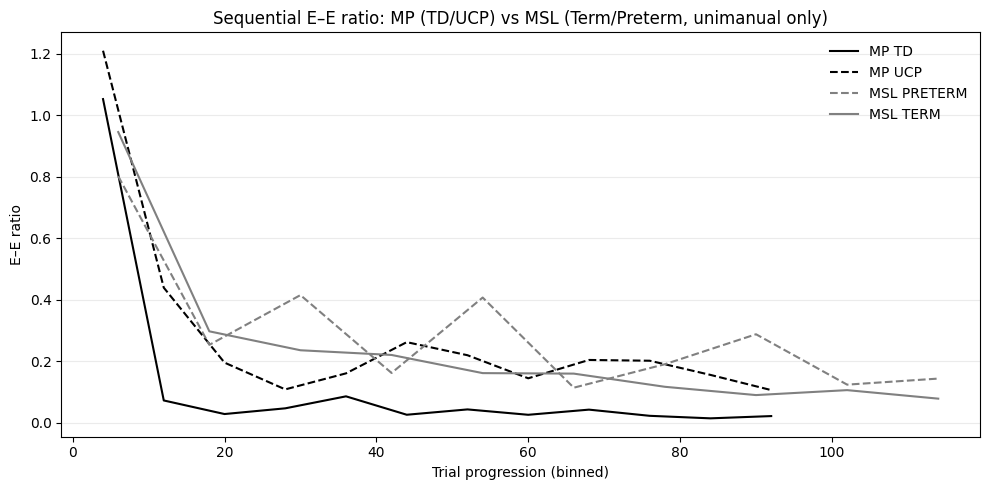

In [11]:
# Parameters for binning
msl_bin = 12
ucpmp_bin = 8

# UCPMP
ucpmp_session_col = [c for c in ['session_no','session','Session','session_id'] if c in uc.columns][0]
ucpmp_trial_col = [c for c in ['trial_seq','trial','trial_no','Trial'] if c in uc.columns][0]
ucpmp_plot = binned_mean(
    uc,
    group_col='cohort_norm',
    unit_col='participant_id',
    session_col=ucpmp_session_col,
    trial_seq_col=ucpmp_trial_col,
    trials_per_session=48,
    expected_total_trials=96,
    bin_size=ucpmp_bin,
    metric=MICRO_COL,
)

# MSL (unimanual only, filter again for safety)
msl_uni_only = ms_uni[ms_uni['task_type'] == 0].copy() if 'task_type' in ms_uni.columns else ms_uni.copy()
msl_session_col = [c for c in ['session_no','session','Session','session_id'] if c in msl_uni_only.columns][0]
msl_trial_col = [c for c in ['trial_seq','trial','trial_no','Trial'] if c in msl_uni_only.columns][0]
msl_plot = binned_mean(
    msl_uni_only,
    group_col='cohort_norm',
    unit_col='participant_id',
    session_col=msl_session_col,
    trial_seq_col=msl_trial_col,
    trials_per_session=24,
    expected_total_trials=120,
    bin_size=msl_bin,
    metric=MICRO_COL,
)

# --- Plot ---
plt.figure(figsize=(10,5))
for g, gdf in ucpmp_plot.groupby('group'):
    plt.plot(gdf['x'], gdf['mean'], label=f'MP {g}', linestyle='-' if g=='TD' else '--', color='black')
for g, gdf in msl_plot.groupby('group'):
    plt.plot(gdf['x'], gdf['mean'], label=f'MSL {g}', linestyle='-' if g=='TERM' else '--', color='gray')
plt.xlabel('Trial progression (binned)')
plt.ylabel('E–E ratio')
plt.title('Sequential E–E ratio: MP (TD/UCP) vs MSL (Term/Preterm, unimanual only)')
plt.legend(frameon=False)
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

## 4. Early vs late learning

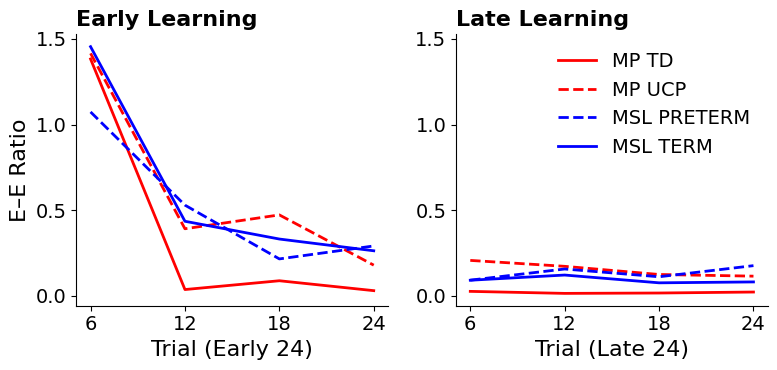

Saved figure to: ../plots/comparison/RQ2/UCPM_vs_MSL_Early_Late.png


In [12]:
# --- Plot early and late learning for MP and MSL unimanual cohorts, shared y-axis, one legend, improved layout ---

def plot_early_late_learning(msl_bin=6, ucpmp_bin=6):

    fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)
    plt.subplots_adjust(wspace=0.15)
    fontsize = 16

    def binned_range(df, group_col, unit_col, session_col, trial_seq_col, trials_per_session, expected_total_trials, bin_size, metric, which):
        d = df.copy()
        d['group'] = d[group_col].astype(str).str.upper()
        d[unit_col] = d[unit_col].astype(str)
        d['trial_index'] = build_global_trial_index(d, unit_col, session_col, trial_seq_col, trials_per_session, expected_total_trials)
        d = d.dropna(subset=['trial_index'])
        d['trial_index'] = d['trial_index'].astype(int)
        out_rows = []
        for (pid, grp), sub in d.groupby([unit_col, 'group']):
            sub = sub.sort_values('trial_index')
            if which == 'early':
                sub = sub.iloc[:24]
                sub['norm_trial'] = np.arange(1, len(sub)+1)
            elif which == 'late':
                sub = sub.iloc[-24:]
                sub['norm_trial'] = np.arange(1, len(sub)+1)
            out_rows.append(sub)
        d2 = pd.concat(out_rows) if out_rows else pd.DataFrame()
        d2[metric] = pd.to_numeric(d2[metric], errors='coerce')
        d2 = d2.dropna(subset=[metric, 'norm_trial'])
        # Bin by norm_trial
        d2['bin'] = ((d2['norm_trial'].astype(int) - 1) // bin_size) + 1
        d2['x'] = d2['bin'] * bin_size  # bin center as trial number
        # Group by group and bin (averaging within each bin)
        out = d2.groupby(['group', 'bin', 'x'], as_index=False)[metric].mean().rename(columns={metric: 'mean'})
        return out

    # Use original loaded dataframes for calculation
    ucpmp_session_col = [c for c in ['session_no','session','Session','session_id'] if c in ucpmp_df.columns][0]
    ucpmp_trial_col = [c for c in ['trial_seq','trial','trial_no','Trial'] if c in ucpmp_df.columns][0]
    msl_session_col = [c for c in ['session_no','session','Session','session_id'] if c in msl_df.columns][0]
    msl_trial_col = [c for c in ['trial_seq','trial','trial_no','Trial'] if c in msl_df.columns][0]
    color_map = {'ucpmp': 'red', 'msl_unimanual': 'blue'}
    style_map = {'TD': '-', 'UCP': '--', 'TERM': '-', 'PRETERM': '--'}

    # Early learning subplot
    ax = axes[0]
    ucpmp_early = binned_range(ucpmp_df, 'Cohort', 'participant_id', ucpmp_session_col, ucpmp_trial_col, 48, 96, ucpmp_bin, MICRO_COL, 'early')
    for g, gdf in ucpmp_early.groupby('group'):
        ax.plot(gdf['x'], gdf['mean'], label=f'MP {g}', color=color_map['ucpmp'], linestyle=style_map.get(g, '-'), linewidth=2)
    ms_uni_early = binned_range(msl_df[msl_df['task_type']==0], 'Cohort', 'participant_id', msl_session_col, msl_trial_col, 24, 120, msl_bin, MICRO_COL, 'early')
    for g, gdf in ms_uni_early.groupby('group'):
        ax.plot(gdf['x'], gdf['mean'], label=f'MSL {g}', color=color_map['msl_unimanual'], linestyle=style_map.get(g, '-'), linewidth=2)
    # Left-align and bold the subplot title
    ax.set_title('Early Learning', fontsize=fontsize, loc='left', fontweight='bold')
    ax.set_xlabel('Trial (Early 24)', fontsize=fontsize)
    ax.set_ylabel('E–E Ratio', fontsize=fontsize)
    # Set x-ticks to bin centers (for both MP and MSL bins)
    xticks = np.unique(np.concatenate([ucpmp_early['x'].unique(), ms_uni_early['x'].unique()]))
    ax.set_xticks(xticks)
    ax.tick_params(axis='both', labelsize=fontsize-2)
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Late learning subplot
    ax2 = axes[1]
    ucpmp_late = binned_range(ucpmp_df, 'Cohort', 'participant_id', ucpmp_session_col, ucpmp_trial_col, 48, 96, ucpmp_bin, MICRO_COL, 'late')
    for g, gdf in ucpmp_late.groupby('group'):
        ax2.plot(gdf['x'], gdf['mean'], label=f'MP {g}', color=color_map['ucpmp'], linestyle=style_map.get(g, '-'), linewidth=2)
    ms_uni_late = binned_range(msl_df[msl_df['task_type']==0], 'Cohort', 'participant_id', msl_session_col, msl_trial_col, 24, 120, msl_bin, MICRO_COL, 'late')
    for g, gdf in ms_uni_late.groupby('group'):
        ax2.plot(gdf['x'], gdf['mean'], label=f'MSL {g}', color=color_map['msl_unimanual'], linestyle=style_map.get(g, '-'), linewidth=2)
    # Left-align and bold the subplot title
    ax2.set_title('Late Learning', fontsize=fontsize, loc='left', fontweight='bold')
    ax2.set_xlabel('Trial (Late 24)', fontsize=fontsize)
    # Set x-ticks to bin centers (for both MP and MSL bins)
    xticks2 = np.unique(np.concatenate([ucpmp_late['x'].unique(), ms_uni_late['x'].unique()]))
    ax2.set_xticks(xticks2)
    ax2.tick_params(axis='both', labelsize=fontsize-2)
    # Remove top and right spines
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    # Show y-axis tick values on right subplot (like RQ3)
    ax2.set_ylabel("")
    ax2.tick_params(axis="y", which="both", left=True, labelleft=True)

    # One legend in the right top of 2nd subplot
    handles, labels = ax2.get_legend_handles_labels()
    ax2.legend(handles, labels, frameon=False, fontsize=fontsize-2, loc='upper right')
    # plt.suptitle('Early vs Late Learning: MP and MSL Unimanual Cohorts', fontsize=fontsize+2)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    # Save to save_path directory
    if "save_path" in globals() and isinstance(save_path, str) and len(save_path.strip()) > 0:
        out_dir = Path(save_path)
    else:
        out_dir = Path(".")
    out_dir.mkdir(parents=True, exist_ok=True)

    out_png = out_dir / f"UCPM_vs_MSL_Early_Late.png"
    fig.savefig(out_png, dpi=600, bbox_inches="tight")
    print(f"Saved figure to: {out_png}")

    plt.show()

# Example usage:
plot_early_late_learning(msl_bin=6, ucpmp_bin=6)

### Statistical analysis

In [9]:
# --- Early and Late Learning Statistical Analysis (t-test, mean±95%CI, p-value) ---

def print_ttest_stats(group1, group2, label1, label2):
    from scipy.stats import ttest_ind, sem, t
    def mean_ci(x):
        x = pd.Series(x).dropna().astype(float)
        n = len(x)
        mean = x.mean()
        if n < 2:
            return mean, np.nan, np.nan
        s = sem(x)
        h = s * t.ppf(0.975, n-1)
        return mean, mean-h, mean+h
    mean1, lo1, hi1 = mean_ci(group1)
    mean2, lo2, hi2 = mean_ci(group2)
    tval, pval = ttest_ind(group1, group2, nan_policy='omit', equal_var=False)[:2]
    print(f"{label1}: {mean1:.4f} [{lo1:.4f}, {hi1:.4f}]  vs  {label2}: {mean2:.4f} [{lo2:.4f}, {hi2:.4f}]  |  p = {pval:.4g}")

# UCPMP: Early = session 1, first 24 trials; Late = session 2, last 24 trials
def get_ucpmp_early_late(df, group_val, session_col, trial_col):
    early = []
    late = []
    for pid, sub in df[df['Cohort']==group_val].groupby('participant_id'):
        # Early: session 1, first 24 trials
        s1 = sub[sub[session_col]==1].sort_values(trial_col)
        if len(s1) >= 24:
            early.extend(s1.iloc[:24][MICRO_COL].values)
        # Late: session 2, last 24 trials
        s2 = sub[sub[session_col]==2].sort_values(trial_col)
        if len(s2) >= 24:
            late.extend(s2.iloc[-24:][MICRO_COL].values)
    return (
        pd.to_numeric(pd.Series(early), errors='coerce').dropna().astype(float),
        pd.to_numeric(pd.Series(late), errors='coerce').dropna().astype(float)
    )

# MSL: Early = trial_seq 1-24; Late = trial_seq 96-120
def get_msl_early_late(df, group_val, task_type):
    early = []
    late = []
    # print(df[(df['Cohort']==group_val) & (df['task_type']==task_type)])
    for pid, sub in df[(df['Cohort']==group_val) & (df['task_type']==task_type)].groupby('participant_id'):
        # print(sub)
        s = sub.sort_values('trial_seq')
        # Early: trial_seq 1-24
        e = s[(s['trial_seq']>=1.0) & (s['trial_seq']<=24.0)][MICRO_COL].values
        # Late: trial_seq 96-120
        l = s[(s['trial_seq']>=96.0) & (s['trial_seq']<=120.0)][MICRO_COL].values
        if len(e) > 0:
            early.extend(e)
        if len(l) > 0:
            late.extend(l)
    return (
        pd.to_numeric(pd.Series(early), errors='coerce').dropna().astype(float),
        pd.to_numeric(pd.Series(late), errors='coerce').dropna().astype(float)
    )

print("--- Early Learning ---")
# UCPMP TD vs UCP
ucpmp_session_col = [c for c in ['session_no','session','Session','session_id'] if c in ucpmp_df.columns][0]
ucpmp_trial_col = [c for c in ['trial_seq','trial','trial_no','Trial'] if c in ucpmp_df.columns][0]
ucpmp_td_early, ucpmp_td_late = get_ucpmp_early_late(ucpmp_df, 'TD', ucpmp_session_col, ucpmp_trial_col)
ucpmp_ucp_early, ucpmp_ucp_late = get_ucpmp_early_late(ucpmp_df, 'UCP', ucpmp_session_col, ucpmp_trial_col)
print_ttest_stats(ucpmp_td_early, ucpmp_ucp_early, 'UCPMP TD', 'UCPMP UCP (Early)')

# MSL Bimanual Preterm vs Term
e_bi_preterm, l_bi_preterm = get_msl_early_late(msl_df, 'Preterm', 1)
e_bi_term, l_bi_term = get_msl_early_late(msl_df, 'Term', 1)
print_ttest_stats(e_bi_preterm, e_bi_term, 'MSL Bimanual Preterm', 'MSL Bimanual Term (Early)')

# MSL Unimanual Preterm vs Term
e_uni_preterm, l_uni_preterm = get_msl_early_late(msl_df, 'Preterm', 0)
e_uni_term, l_uni_term = get_msl_early_late(msl_df, 'Term', 0)
print_ttest_stats(e_uni_preterm, e_uni_term, 'MSL Unimanual Preterm', 'MSL Unimanual Term (Early)')

print("\n--- Late Learning ---")
# UCPMP TD vs UCP
print_ttest_stats(ucpmp_td_late, ucpmp_ucp_late, 'UCPMP TD', 'UCPMP UCP (Late)')
# MSL Bimanual Preterm vs Term
print_ttest_stats(l_bi_preterm, l_bi_term, 'MSL Bimanual Preterm', 'MSL Bimanual Term (Late)')
# MSL Unimanual Preterm vs Term
print_ttest_stats(l_uni_preterm, l_uni_term, 'MSL Unimanual Preterm', 'MSL Unimanual Term (Late)')


--- Early Learning ---
UCPMP TD: 0.3840 [0.2838, 0.4842]  vs  UCPMP UCP (Early): 0.6144 [0.3822, 0.8466]  |  p = 0.07371
MSL Bimanual Preterm: 0.8039 [0.6394, 0.9683]  vs  MSL Bimanual Term (Early): 0.6624 [0.5755, 0.7494]  |  p = 0.1356
MSL Unimanual Preterm: 0.6051 [0.4782, 0.7321]  vs  MSL Unimanual Term (Early): 0.5966 [0.5211, 0.6721]  |  p = 0.9092

--- Late Learning ---
UCPMP TD: 0.0190 [0.0137, 0.0244]  vs  UCPMP UCP (Late): 0.1540 [0.1058, 0.2022]  |  p = 1.035e-07
MSL Bimanual Preterm: 0.2425 [0.1743, 0.3107]  vs  MSL Bimanual Term (Late): 0.1703 [0.1478, 0.1927]  |  p = 0.04848
MSL Unimanual Preterm: 0.1313 [0.0914, 0.1713]  vs  MSL Unimanual Term (Late): 0.1107 [0.0969, 0.1246]  |  p = 0.3385


In [10]:
import numpy as np
import pandas as pd
import scipy.stats as stats

MICRO_COL = "exploration_exploitation_ratio"

def ci95(x):
    x = pd.to_numeric(pd.Series(x), errors="coerce").dropna().astype(float)
    n = len(x)
    if n == 0:
        return np.nan, np.nan, np.nan, 0
    mean = float(x.mean())
    if n < 2:
        return mean, np.nan, np.nan, n
    h = stats.t.ppf(0.975, n - 1) * stats.sem(x, nan_policy="omit")
    return mean, mean - float(h), mean + float(h), n

def welch_p(x, y):
    x = pd.to_numeric(pd.Series(x), errors="coerce").dropna().astype(float)
    y = pd.to_numeric(pd.Series(y), errors="coerce").dropna().astype(float)
    if len(x) < 2 or len(y) < 2:
        return np.nan
    return stats.ttest_ind(x, y, equal_var=False, nan_policy="omit").pvalue

def print_group_compare(group1, group2, label1, label2, phase_label):
    m1, lo1, hi1, n1 = ci95(group1)
    m2, lo2, hi2, n2 = ci95(group2)
    p = welch_p(group1, group2)
    print(f"{phase_label}")
    print(f"  {label1}: {m1:.4f} [{lo1:.4f}, {hi1:.4f}]  (n={n1})")
    print(f"  {label2}: {m2:.4f} [{lo2:.4f}, {hi2:.4f}]  (n={n2})")
    print(f"  Welch p = {p:.4g}\n")

def print_paired_compare(early_vals, late_vals, label):
    early_vals = pd.to_numeric(pd.Series(early_vals), errors="coerce").dropna().astype(float)
    late_vals = pd.to_numeric(pd.Series(late_vals), errors="coerce").dropna().astype(float)
    n = min(len(early_vals), len(late_vals))
    if n < 2:
        print(f"  {label}: insufficient paired samples (n={n})")
        return
    t_stat, p_val = stats.ttest_rel(early_vals[:n], late_vals[:n], nan_policy="omit")
    m_e, lo_e, hi_e, n_e = ci95(early_vals)
    m_l, lo_l, hi_l, n_l = ci95(late_vals)
    print(f"  {label}: Early {m_e:.4f} [{lo_e:.4f}, {hi_e:.4f}] (n={n_e}) vs Late {m_l:.4f} [{lo_l:.4f}, {hi_l:.4f}] (n={n_l}) | paired p = {p_val:.4g}")

# UCPMP: Early = session 1 first 24 trials; Late = session 2 last 24 trials
def get_ucpmp_early_late(df, group_val, session_col, trial_col):
    early = []
    late = []
    for _, sub in df[df["Cohort"] == group_val].groupby("participant_id"):
        s1 = sub[sub[session_col] == 1].sort_values(trial_col)
        if len(s1) >= 24:
            early.extend(s1.iloc[:24][MICRO_COL].values)
        s2 = sub[sub[session_col] == 2].sort_values(trial_col)
        if len(s2) >= 24:
            late.extend(s2.iloc[-24:][MICRO_COL].values)
    return (
        pd.to_numeric(pd.Series(early), errors="coerce").dropna().astype(float),
        pd.to_numeric(pd.Series(late), errors="coerce").dropna().astype(float),
    )

def get_ucpmp_early_late_by_participant(df, group_val, session_col, trial_col):
    early_means = []
    late_means = []
    for _, sub in df[df["Cohort"] == group_val].groupby("participant_id"):
        s1 = sub[sub[session_col] == 1].sort_values(trial_col)
        s2 = sub[sub[session_col] == 2].sort_values(trial_col)
        if len(s1) >= 24 and len(s2) >= 24:
            e = pd.to_numeric(s1.iloc[:24][MICRO_COL], errors="coerce").mean()
            l = pd.to_numeric(s2.iloc[-24:][MICRO_COL], errors="coerce").mean()
            if np.isfinite(e) and np.isfinite(l):
                early_means.append(e)
                late_means.append(l)
    return early_means, late_means

# MSL: Early = trial_seq 1-24; Late = trial_seq 96-120
def get_msl_early_late(df, group_val, task_type):
    early = []
    late = []
    for _, sub in df[(df["Cohort"] == group_val) & (df["task_type"] == task_type)].groupby("participant_id"):
        s = sub.sort_values("trial_seq")
        e = s[(s["trial_seq"] >= 1.0) & (s["trial_seq"] <= 24.0)][MICRO_COL].values
        l = s[(s["trial_seq"] >= 96.0) & (s["trial_seq"] <= 120.0)][MICRO_COL].values
        if len(e) > 0:
            early.extend(e)
        if len(l) > 0:
            late.extend(l)
    return (
        pd.to_numeric(pd.Series(early), errors="coerce").dropna().astype(float),
        pd.to_numeric(pd.Series(late), errors="coerce").dropna().astype(float),
    )

def get_msl_early_late_by_participant(df, group_val, task_type):
    early_means = []
    late_means = []
    for _, sub in df[(df["Cohort"] == group_val) & (df["task_type"] == task_type)].groupby("participant_id"):
        s = sub.sort_values("trial_seq")
        e = pd.to_numeric(s[(s["trial_seq"] >= 1.0) & (s["trial_seq"] <= 24.0)][MICRO_COL], errors="coerce")
        l = pd.to_numeric(s[(s["trial_seq"] >= 96.0) & (s["trial_seq"] <= 120.0)][MICRO_COL], errors="coerce")
        if len(e) > 0 and len(l) > 0:
            e_m = float(e.mean())
            l_m = float(l.mean())
            if np.isfinite(e_m) and np.isfinite(l_m):
                early_means.append(e_m)
                late_means.append(l_m)
    return early_means, late_means

# ---- UCPMP (TD vs UCP) ----
ucpmp_session_col = [c for c in ["session_no", "session", "Session", "session_id"] if c in ucpmp_df.columns][0]
ucpmp_trial_col = [c for c in ["trial_seq", "trial", "trial_no", "Trial"] if c in ucpmp_df.columns][0]
ucpmp_td_early, ucpmp_td_late = get_ucpmp_early_late(ucpmp_df, "TD", ucpmp_session_col, ucpmp_trial_col)
ucpmp_ucp_early, ucpmp_ucp_late = get_ucpmp_early_late(ucpmp_df, "UCP", ucpmp_session_col, ucpmp_trial_col)

print("UCPMP (simple task):")
print_group_compare(ucpmp_td_early, ucpmp_ucp_early, "TD (Early)", "UCP (Early)", "  Early")
print_group_compare(ucpmp_td_late, ucpmp_ucp_late, "TD (Late)", "UCP (Late)", "  Late")

# ---- MSL Unimanual (Term vs Preterm) ----
e_uni_preterm, l_uni_preterm = get_msl_early_late(msl_df, "Preterm", 0)
e_uni_term, l_uni_term = get_msl_early_late(msl_df, "Term", 0)

print("MSL Unimanual (complex task):")
print_group_compare(e_uni_term, e_uni_preterm, "Term (Early)", "Preterm (Early)", "  Early")
print_group_compare(l_uni_term, l_uni_preterm, "Term (Late)", "Preterm (Late)", "  Late")

# ---- MSL Bimanual (Term vs Preterm) ----
e_bi_preterm, l_bi_preterm = get_msl_early_late(msl_df, "Preterm", 1)
e_bi_term, l_bi_term = get_msl_early_late(msl_df, "Term", 1)

print("MSL Bimanual (complex task):")
print_group_compare(e_bi_term, e_bi_preterm, "Term (Early)", "Preterm (Early)", "  Early")
print_group_compare(l_bi_term, l_bi_preterm, "Term (Late)", "Preterm (Late)", "  Late")

print("\nWithin-cohort Early vs Late (paired):")
td_e, td_l = get_ucpmp_early_late_by_participant(ucpmp_df, "TD", ucpmp_session_col, ucpmp_trial_col)
ucp_e, ucp_l = get_ucpmp_early_late_by_participant(ucpmp_df, "UCP", ucpmp_session_col, ucpmp_trial_col)
print("UCPMP (simple task):")
print_paired_compare(td_e, td_l, "TD")
print_paired_compare(ucp_e, ucp_l, "UCP")

term_u_e, term_u_l = get_msl_early_late_by_participant(msl_df, "Term", 0)
pre_u_e, pre_u_l = get_msl_early_late_by_participant(msl_df, "Preterm", 0)
print("MSL Unimanual (complex task):")
print_paired_compare(term_u_e, term_u_l, "Term")
print_paired_compare(pre_u_e, pre_u_l, "Preterm")

term_b_e, term_b_l = get_msl_early_late_by_participant(msl_df, "Term", 1)
pre_b_e, pre_b_l = get_msl_early_late_by_participant(msl_df, "Preterm", 1)
print("MSL Bimanual (complex task):")
print_paired_compare(term_b_e, term_b_l, "Term")
print_paired_compare(pre_b_e, pre_b_l, "Preterm")

UCPMP (simple task):
  Early
  TD (Early): 0.3840 [0.2838, 0.4842]  (n=960)
  UCP (Early): 0.6144 [0.3822, 0.8466]  (n=240)
  Welch p = 0.07371

  Late
  TD (Late): 0.0190 [0.0137, 0.0244]  (n=960)
  UCP (Late): 0.1540 [0.1058, 0.2022]  (n=240)
  Welch p = 1.035e-07

MSL Unimanual (complex task):
  Early
  Term (Early): 0.5966 [0.5211, 0.6721]  (n=1200)
  Preterm (Early): 0.6051 [0.4782, 0.7321]  (n=432)
  Welch p = 0.9092

  Late
  Term (Late): 0.1107 [0.0969, 0.1246]  (n=1250)
  Preterm (Late): 0.1313 [0.0914, 0.1713]  (n=450)
  Welch p = 0.3385



MSL Bimanual (complex task):
  Early
  Term (Early): 0.6624 [0.5755, 0.7494]  (n=1200)
  Preterm (Early): 0.8039 [0.6394, 0.9683]  (n=432)
  Welch p = 0.1356

  Late
  Term (Late): 0.1703 [0.1478, 0.1927]  (n=1250)
  Preterm (Late): 0.2425 [0.1743, 0.3107]  (n=450)
  Welch p = 0.04848


Within-cohort Early vs Late (paired):
UCPMP (simple task):
  TD: Early 0.3840 [0.3090, 0.4590] (n=40) vs Late 0.0190 [0.0122, 0.0259] (n=40) | paired p = 1.933e-12
  UCP: Early 0.6144 [0.3214, 0.9074] (n=10) vs Late 0.1540 [-0.0020, 0.3101] (n=10) | paired p = 0.01004
MSL Unimanual (complex task):
  Term: Early 0.5966 [0.5387, 0.6544] (n=50) vs Late 0.1107 [0.0831, 0.1384] (n=50) | paired p = 1.122e-21
  Preterm: Early 0.6051 [0.4914, 0.7189] (n=18) vs Late 0.1313 [0.0780, 0.1847] (n=18) | paired p = 2.888e-07
MSL Bimanual (complex task):
  Term: Early 0.6624 [0.6031, 0.7217] (n=50) vs Late 0.1703 [0.1402, 0.2003] (n=50) | paired p = 5.599e-21
  Preterm: Early 0.8039 [0.6779, 0.9298] (n=18) vs Late 0.24

In [11]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

MICRO_COL = "exploration_exploitation_ratio"

# --- Build combined dataset ---
uc = ucpmp_df.copy()
uc["task"] = "simple"
uc["cohort"] = uc["Cohort"].astype(str).str.strip().str.upper().replace(
    {"UCPMP":"UCP","UCP":"UCP","TD":"TD","TDC":"TD","CONTROL":"TD","TYPICAL":"TD"}
)

ms = msl_df.copy()
ms["task"] = "complex"
ms["cohort"] = ms["Cohort"].astype(str).str.strip().str.upper().replace(
    {"TERM":"TERM","PRETERM":"PRETERM","PRE-TERM":"PRETERM","PT":"PRETERM"}
)

df = pd.concat([uc, ms], ignore_index=True)
df = df[df["cohort"].isin(["TD","UCP","TERM","PRETERM"])]

# --- One-way ANOVA across all cohorts ---
model_all = smf.ols(f"{MICRO_COL} ~ C(cohort)", data=df).fit()
anova_all = sm.stats.anova_lm(model_all, typ=2)
print("One-way ANOVA (All cohorts combined):")
print(anova_all, "\n")

# --- One-way ANOVA within each task ---
model_simple = smf.ols(f"{MICRO_COL} ~ C(cohort)", data=df[df["task"]=="simple"]).fit()
anova_simple = sm.stats.anova_lm(model_simple, typ=2)
print("One-way ANOVA (UCPMP only):")
print(anova_simple, "\n")

model_complex = smf.ols(f"{MICRO_COL} ~ C(cohort)", data=df[df["task"]=="complex"]).fit()
anova_complex = sm.stats.anova_lm(model_complex, typ=2)
print("One-way ANOVA (MSL only):")
print(anova_complex)

One-way ANOVA (All cohorts combined):
                 sum_sq       df          F        PR(>F)
C(cohort)     86.284816      3.0  39.929711  1.011907e-25
Residual   15209.978863  21116.0        NaN           NaN 

One-way ANOVA (UCPMP only):
                sum_sq      df          F        PR(>F)
C(cohort)    19.766269     1.0  25.107516  5.616945e-07
Residual   3777.297628  4798.0        NaN           NaN 

One-way ANOVA (MSL only):
                 sum_sq       df         F    PR(>F)
C(cohort)      6.526630      1.0  9.315536  0.002276
Residual   11432.681235  16318.0       NaN       NaN


In [13]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

MICRO_COL = "exploration_exploitation_ratio"

# MSL only
ms = msl_df.copy()

# Normalize cohort/task
ms["cohort"] = ms["Cohort"].astype(str).str.strip().str.upper().replace(
    {"TERM": "TERM", "PRETERM": "PRETERM", "PRE-TERM": "PRETERM", "PT": "PRETERM"}
)
ms["task"] = pd.to_numeric(ms["task_type"], errors="coerce")  # 0=uni, 1=bi

# Define early/late phase based on trial_seq
ms["trial_seq"] = pd.to_numeric(ms["trial_seq"], errors="coerce")
ms["phase"] = pd.NA
ms.loc[ms["trial_seq"].between(1, 24, inclusive="both"), "phase"] = "early"
ms.loc[ms["trial_seq"].between(96, 120, inclusive="both"), "phase"] = "late"

# Keep only early/late windows and unimanual task only
ms_anova = ms.dropna(subset=[MICRO_COL, "cohort", "task", "phase"]).copy()
ms_anova = ms_anova[ms_anova["phase"].isin(["early", "late"])].copy()
ms_anova = ms_anova[ms_anova["task"] == 0].copy()  # Unimanual only

# Two-way ANOVA with cohort x phase (unimanual task only)
model = smf.ols(f"{MICRO_COL} ~ C(cohort) * C(phase)", data=ms_anova).fit()
anova = sm.stats.anova_lm(model, typ=2)
print("ANOVA (MSL Unimanual only): cohort x phase")
print(anova)

ANOVA (MSL Unimanual only): cohort x phase
                         sum_sq      df           F        PR(>F)
C(cohort)              0.140344     1.0    0.152195  6.964714e-01
C(phase)             193.954991     1.0  210.333171  2.908611e-46
C(cohort):C(phase)     0.023429     1.0    0.025408  8.733644e-01
Residual            3068.855985  3328.0         NaN           NaN


In [13]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

MICRO_COL = "exploration_exploitation_ratio"

# --- UCPMP only: cohort x phase ANOVA (early vs late) ---
uc = ucpmp_df.copy()
cohort_col = [c for c in ["Cohort","cohort","GROUP","Group","group"] if c in uc.columns][0]
uc["cohort"] = (
    uc[cohort_col].astype(str).str.strip().str.upper()
    .replace({"UCPMP":"UCP","UCP":"UCP","TD":"TD","TDC":"TD","CONTROL":"TD","TYPICAL":"TD"})
)
uc = uc[uc["cohort"].isin(["TD","UCP"])].copy()

session_col = [c for c in ["session_no","session","Session","session_id"] if c in uc.columns][0]
trial_col = [c for c in ["trial_seq","trial","trial_no","Trial"] if c in uc.columns][0]
uc[trial_col] = pd.to_numeric(uc[trial_col], errors="coerce")

def _mark_phase(sub):
    sub = sub.sort_values(trial_col).copy()
    sub["phase"] = pd.NA
    if int(sub[session_col].iloc[0]) == 1:
        sub.iloc[:24, sub.columns.get_loc("phase")] = "early"
    elif int(sub[session_col].iloc[0]) == 2:
        sub.iloc[-24:, sub.columns.get_loc("phase")] = "late"
    return sub

uc = (
    uc.dropna(subset=[trial_col])
      .groupby(["participant_id", session_col], group_keys=False)
      .apply(_mark_phase)
      .reset_index(drop=True)
 )
uc_phase = uc[uc["phase"].isin(["early","late"])].copy()
uc_phase = uc_phase.dropna(subset=[MICRO_COL])

model = smf.ols(f"{MICRO_COL} ~ C(cohort) * C(phase)", data=uc_phase).fit()
anova = sm.stats.anova_lm(model, typ=2)
print("UCPMP ANOVA: cohort x phase (early/late)")
print(anova)

UCPMP ANOVA: cohort x phase (early/late)
                         sum_sq      df          F        PR(>F)
C(cohort)             12.818937     1.0   9.487619  2.092116e-03
C(phase)              88.490388     1.0  65.493969  9.169149e-16
C(cohort):C(phase)     0.874422     1.0   0.647182  4.212018e-01
Residual            3237.289987  2396.0        NaN           NaN


/var/folders/c5/gxvjzbzd36x1q68jgw7v4zl80000gn/T/ipykernel_76483/3966016428.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  uc.dropna(subset=[trial_col])


In [14]:
# --- Simple vs Complex task effect on rehabilitation (participant-level early/late) ---
import numpy as np
import pandas as pd
import scipy.stats as stats

MICRO_COL = "exploration_exploitation_ratio"

def ci95(x):
    x = pd.to_numeric(pd.Series(x), errors="coerce").dropna().astype(float)
    n = len(x)
    if n == 0:
        return np.nan, np.nan, np.nan, 0
    mean = float(x.mean())
    if n < 2:
        return mean, np.nan, np.nan, n
    h = stats.t.ppf(0.975, n - 1) * stats.sem(x, nan_policy="omit")
    return mean, mean - float(h), mean + float(h), n

def welch_p(x, y):
    x = pd.to_numeric(pd.Series(x), errors="coerce").dropna().astype(float)
    y = pd.to_numeric(pd.Series(y), errors="coerce").dropna().astype(float)
    if len(x) < 2 or len(y) < 2:
        return np.nan
    return stats.ttest_ind(x, y, equal_var=False, nan_policy="omit").pvalue

def summarize_phase(label, early_vals, late_vals):
    m_e, lo_e, hi_e, n_e = ci95(early_vals)
    m_l, lo_l, hi_l, n_l = ci95(late_vals)
    print(f"{label}")
    print(f"  Early: {m_e:.4f} [{lo_e:.4f}, {hi_e:.4f}] (n={n_e})")
    print(f"  Late:  {m_l:.4f} [{lo_l:.4f}, {hi_l:.4f}] (n={n_l})")
    return np.asarray(early_vals, dtype=float), np.asarray(late_vals, dtype=float)

def compare_delta(label, delta_a, delta_b):
    p = welch_p(delta_a, delta_b)
    m_a, lo_a, hi_a, n_a = ci95(delta_a)
    m_b, lo_b, hi_b, n_b = ci95(delta_b)
    print(f"{label}")
    print(f"  Group A: {m_a:.4f} [{lo_a:.4f}, {hi_a:.4f}] (n={n_a})")
    print(f"  Group B: {m_b:.4f} [{lo_b:.4f}, {hi_b:.4f}] (n={n_b})")
    print(f"  Welch p = {p:.4g}\n")

def get_ucpmp_early_late_by_participant(df, group_val, session_col, trial_col):
    early_means = []
    late_means = []
    for _, sub in df[df["Cohort"] == group_val].groupby("participant_id"):
        s1 = sub[sub[session_col] == 1].sort_values(trial_col)
        s2 = sub[sub[session_col] == 2].sort_values(trial_col)
        if len(s1) >= 24 and len(s2) >= 24:
            e = pd.to_numeric(s1.iloc[:24][MICRO_COL], errors="coerce").mean()
            l = pd.to_numeric(s2.iloc[-24:][MICRO_COL], errors="coerce").mean()
            if np.isfinite(e) and np.isfinite(l):
                early_means.append(e)
                late_means.append(l)
    return early_means, late_means

def get_msl_early_late_by_participant(df, group_val, task_type):
    early_means = []
    late_means = []
    for _, sub in df[(df["Cohort"] == group_val) & (df["task_type"] == task_type)].groupby("participant_id"):
        s = sub.sort_values("trial_seq")
        e = pd.to_numeric(s[(s["trial_seq"] >= 1.0) & (s["trial_seq"] <= 24.0)][MICRO_COL], errors="coerce")
        l = pd.to_numeric(s[(s["trial_seq"] >= 96.0) & (s["trial_seq"] <= 120.0)][MICRO_COL], errors="coerce")
        if len(e) > 0 and len(l) > 0:
            e_m = float(e.mean())
            l_m = float(l.mean())
            if np.isfinite(e_m) and np.isfinite(l_m):
                early_means.append(e_m)
                late_means.append(l_m)
    return early_means, late_means

# UCPMP (simple task)
ucpmp_session_col = [c for c in ["session_no", "session", "Session", "session_id"] if c in ucpmp_df.columns][0]
ucpmp_trial_col = [c for c in ["trial_seq", "trial", "trial_no", "Trial"] if c in ucpmp_df.columns][0]
td_e, td_l = get_ucpmp_early_late_by_participant(ucpmp_df, "TD", ucpmp_session_col, ucpmp_trial_col)
ucp_e, ucp_l = get_ucpmp_early_late_by_participant(ucpmp_df, "UCP", ucpmp_session_col, ucpmp_trial_col)

# MSL (complex task)
term_u_e, term_u_l = get_msl_early_late_by_participant(msl_df, "Term", 0)
pre_u_e, pre_u_l = get_msl_early_late_by_participant(msl_df, "Preterm", 0)
term_b_e, term_b_l = get_msl_early_late_by_participant(msl_df, "Term", 1)
pre_b_e, pre_b_l = get_msl_early_late_by_participant(msl_df, "Preterm", 1)

print("Simple vs Complex task effect on rehabilitation (participant-level)")
print("UCPMP (simple):")
summarize_phase("  TD", td_e, td_l)
summarize_phase("  UCP", ucp_e, ucp_l)
print("MSL Unimanual (complex):")
summarize_phase("  Term", term_u_e, term_u_l)
summarize_phase("  Preterm", pre_u_e, pre_u_l)
print("MSL Bimanual (complex):")
summarize_phase("  Term", term_b_e, term_b_l)
summarize_phase("  Preterm", pre_b_e, pre_b_l)

# Compare early->late change (delta) across tasks for impaired vs control
td_delta = np.asarray(td_l) - np.asarray(td_e)
ucp_delta = np.asarray(ucp_l) - np.asarray(ucp_e)
term_u_delta = np.asarray(term_u_l) - np.asarray(term_u_e)
pre_u_delta = np.asarray(pre_u_l) - np.asarray(pre_u_e)
term_b_delta = np.asarray(term_b_l) - np.asarray(term_b_e)
pre_b_delta = np.asarray(pre_b_l) - np.asarray(pre_b_e)

print("\nEarly→Late change (Late - Early) across tasks:")
compare_delta("Impaired: UCP (simple) vs Preterm (complex, unimanual)", ucp_delta, pre_u_delta)
compare_delta("Impaired: UCP (simple) vs Preterm (complex, bimanual)", ucp_delta, pre_b_delta)
compare_delta("Control: TD (simple) vs Term (complex, unimanual)", td_delta, term_u_delta)
compare_delta("Control: TD (simple) vs Term (complex, bimanual)", td_delta, term_b_delta)

Simple vs Complex task effect on rehabilitation (participant-level)
UCPMP (simple):
  TD
  Early: 0.3840 [0.3090, 0.4590] (n=40)
  Late:  0.0190 [0.0122, 0.0259] (n=40)
  UCP
  Early: 0.6144 [0.3214, 0.9074] (n=10)
  Late:  0.1540 [-0.0020, 0.3101] (n=10)
MSL Unimanual (complex):
  Term
  Early: 0.5966 [0.5387, 0.6544] (n=50)
  Late:  0.1107 [0.0831, 0.1384] (n=50)
  Preterm
  Early: 0.6051 [0.4914, 0.7189] (n=18)
  Late:  0.1313 [0.0780, 0.1847] (n=18)
MSL Bimanual (complex):
  Term
  Early: 0.6624 [0.6031, 0.7217] (n=50)
  Late:  0.1703 [0.1402, 0.2003] (n=50)
  Preterm
  Early: 0.8039 [0.6779, 0.9298] (n=18)
  Late:  0.2425 [0.1677, 0.3173] (n=18)

Early→Late change (Late - Early) across tasks:
Impaired: UCP (simple) vs Preterm (complex, unimanual)
  Group A: -0.4604 [-0.7811, -0.1397] (n=10)
  Group B: -0.4738 [-0.5966, -0.3510] (n=18)
  Welch p = 0.9317

Impaired: UCP (simple) vs Preterm (complex, bimanual)
  Group A: -0.4604 [-0.7811, -0.1397] (n=10)
  Group B: -0.5614 [-0.6931, 

In [15]:
# --- Late-phase comparison across cohorts (TD, UCP, Term Bi, Preterm Bi) ---
import numpy as np
import pandas as pd
import scipy.stats as stats

MICRO_COL = "exploration_exploitation_ratio"

def ci95(x):
    x = pd.to_numeric(pd.Series(x), errors="coerce").dropna().astype(float)
    n = len(x)
    if n == 0:
        return np.nan, np.nan, np.nan, 0
    mean = float(x.mean())
    if n < 2:
        return mean, np.nan, np.nan, n
    h = stats.t.ppf(0.975, n - 1) * stats.sem(x, nan_policy="omit")
    return mean, mean - float(h), mean + float(h), n

def welch_p(x, y):
    x = pd.to_numeric(pd.Series(x), errors="coerce").dropna().astype(float)
    y = pd.to_numeric(pd.Series(y), errors="coerce").dropna().astype(float)
    if len(x) < 2 or len(y) < 2:
        return np.nan
    return stats.ttest_ind(x, y, equal_var=False, nan_policy="omit").pvalue

# UCPMP late (session 2 last 24 trials)
ucpmp_session_col = [c for c in ["session_no", "session", "Session", "session_id"] if c in ucpmp_df.columns][0]
ucpmp_trial_col = [c for c in ["trial_seq", "trial", "trial_no", "Trial"] if c in ucpmp_df.columns][0]

def get_ucpmp_late(df, cohort):
    late = []
    for _, sub in df[df["Cohort"] == cohort].groupby("participant_id"):
        s2 = sub[sub[ucpmp_session_col] == 2].sort_values(ucpmp_trial_col)
        if len(s2) >= 24:
            late.extend(s2.iloc[-24:][MICRO_COL].values)
    return pd.to_numeric(pd.Series(late), errors="coerce").dropna().astype(float)

# MSL bimanual late (trial_seq 96-120)
def get_msl_bi_late(df, cohort):
    late = []
    for _, sub in df[(df["Cohort"] == cohort) & (df["task_type"] == 1)].groupby("participant_id"):
        s = sub.sort_values("trial_seq")
        l = s[(s["trial_seq"] >= 96.0) & (s["trial_seq"] <= 120.0)][MICRO_COL].values
        if len(l) > 0:
            late.extend(l)
    return pd.to_numeric(pd.Series(late), errors="coerce").dropna().astype(float)

td_late = get_ucpmp_late(ucpmp_df, "TD")
ucp_late = get_ucpmp_late(ucpmp_df, "UCP")
term_b_late = get_msl_bi_late(msl_df, "Term")
preterm_b_late = get_msl_bi_late(msl_df, "Preterm")

groups = {
    "TD (Late)": td_late,
    "UCP (Late)": ucp_late,
    "Term (Bi) Late": term_b_late,
    "Preterm (Bi) Late": preterm_b_late,
}

print("Late-phase mean ± 95% CI")
for label, vals in groups.items():
    m, lo, hi, n = ci95(vals)
    print(f"  {label}: {m:.4f} [{lo:.4f}, {hi:.4f}] (n={n})")

print("\nPairwise Welch p-values (late phase)")
labels = list(groups.keys())
for i in range(len(labels)):
    for j in range(i + 1, len(labels)):
        a = groups[labels[i]]
        b = groups[labels[j]]
        p = welch_p(a, b)
        print(f"  {labels[i]} vs {labels[j]}: p = {p:.4g}")

Late-phase mean ± 95% CI
  TD (Late): 0.0190 [0.0137, 0.0244] (n=960)
  UCP (Late): 0.1540 [0.1058, 0.2022] (n=240)
  Term (Bi) Late: 0.1703 [0.1478, 0.1927] (n=1250)
  Preterm (Bi) Late: 0.2425 [0.1743, 0.3107] (n=450)

Pairwise Welch p-values (late phase)
  TD (Late) vs UCP (Late): p = 1.035e-07
  TD (Late) vs Term (Bi) Late: p = 8.567e-36
  TD (Late) vs Preterm (Bi) Late: p = 3.386e-10
  UCP (Late) vs Term (Bi) Late: p = 0.5479
  UCP (Late) vs Preterm (Bi) Late: p = 0.03748
  Term (Bi) Late vs Preterm (Bi) Late: p = 0.04848


### Case study: Optimal Strategy Detection

In [15]:
# print(msl_df.columns)
print(msl_df["participant_id"].where(msl_df["Cohort"] == "Preterm").dropna().unique())
print(msl_df["participant_id"].where(msl_df["Cohort"] == "Term").dropna().unique())

['MTRLRN002' 'MTRLRN013' 'MTRLRN029' 'MTRLRN030' 'MTRLRN031' 'MTRLRN038'
 'MTRLRN039' 'MTRLRN043' 'MTRLRN044' 'MTRLRN045' 'MTRLRN048' 'MTRLRN055'
 'MTRLRN056' 'MTRLRN058' 'MTRLRN060' 'MTRLRN062' 'MTRLRN064' 'MTRLRN065']
['MTRLRN004' 'MTRLRN005' 'MTRLRN007' 'MTRLRN008' 'MTRLRN009' 'MTRLRN010'
 'MTRLRN011' 'MTRLRN012' 'MTRLRN014' 'MTRLRN015' 'MTRLRN016' 'MTRLRN017'
 'MTRLRN019' 'MTRLRN020' 'MTRLRN021' 'MTRLRN022' 'MTRLRN025' 'MTRLRN026'
 'MTRLRN027' 'MTRLRN032' 'MTRLRN033' 'MTRLRN035' 'MTRLRN036' 'MTRLRN037'
 'MTRLRN040' 'MTRLRN041' 'MTRLRN042' 'MTRLRN046' 'MTRLRN047' 'MTRLRN049'
 'MTRLRN050' 'MTRLRN051' 'MTRLRN052' 'MTRLRN053' 'MTRLRN054' 'MTRLRN057'
 'MTRLRN066' 'MTRLRN067' 'MTRLRN068' 'MTRLRN069' 'MTRLRN070' 'MTRLRN071'
 'MTRLRN072' 'MTRLRN073' 'MTRLRN074' 'MTRLRN075' 'MTRLRN076' 'MTRLRN077'
 'MTRLRN078' 'MTRLRN079']


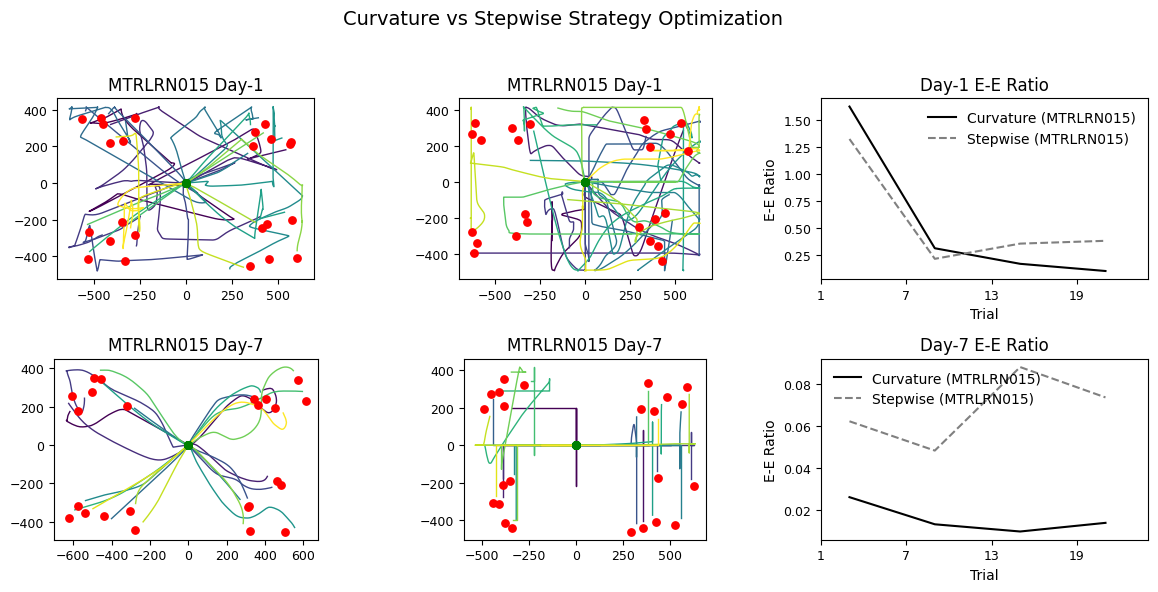

In [17]:
# --- Case study: Curvature vs Stepwise strategy (6-panel figure) ---
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MICRO_COL = "exploration_exploitation_ratio"

def _find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def _parse_path(val):
    if isinstance(val, (list, tuple, np.ndarray)):
        arr = np.asarray(val)
    elif isinstance(val, str):
        try:
            arr = np.asarray(ast.literal_eval(val))
        except Exception:
            return None
    else:
        return None
    if arr.ndim == 1 and arr.size % 2 == 0:
        arr = arr.reshape(-1, 2)
    if arr.ndim >= 2 and arr.shape[1] >= 2:
        return arr[:, 0], arr[:, 1]
    return None

def _filter_subset(df, pid, session_no, task_type):
    session_col = _find_col(df, ["session_no", "session", "Session", "session_id"])
    task_col = _find_col(df, ["task_type", "task", "Task"])
    if session_col is None or task_col is None:
        return None
    sub = df.copy()
    sub = sub[sub["participant_id"].astype(str) == str(pid)]
    sub = sub[pd.to_numeric(sub[task_col], errors="coerce") == int(task_type)]
    sub = sub[pd.to_numeric(sub[session_col], errors="coerce") == int(session_no)]
    return sub

def _get_paths(df, pid, session_no, task_type):
    path_col = _find_col(df, ["path", "Path", "trajectory", "traj", "trajectory_path"])
    trial_col = _find_col(df, ["trial_seq", "trial", "trial_no", "Trial"])
    sx_col = _find_col(df, ["start_point_x"])
    sy_col = _find_col(df, ["start_point_y"])
    tx_col = _find_col(df, ["target_point_x"])
    ty_col = _find_col(df, ["target_point_y"])
    if path_col is None:
        return []
    sub = _filter_subset(df, pid, session_no, task_type)
    if sub is None or sub.empty:
        return []
    if trial_col is not None:
        sub[trial_col] = pd.to_numeric(sub[trial_col], errors="coerce")
        sub = sub.sort_values(trial_col)
    paths = []
    for _, row in sub.iterrows():
        parsed = _parse_path(row[path_col])
        if parsed is None:
            continue
        sx = sy = tx = ty = None
        if None not in (sx_col, sy_col, tx_col, ty_col):
            try:
                sx = float(row[sx_col])
                sy = float(row[sy_col])
                tx = float(row[tx_col])
                ty = float(row[ty_col])
            except Exception:
                sx = sy = tx = ty = None
        paths.append((parsed[0], parsed[1], sx, sy, tx, ty))
    return paths

def _get_ee_series(df, pid, session_no, task_type):
    session_col = _find_col(df, ["session_no", "session", "Session", "session_id"])
    trial_col = _find_col(df, ["trial_seq", "trial", "trial_no", "Trial"])
    task_col = _find_col(df, ["task_type", "task", "Task"])
    if session_col is None or trial_col is None or task_col is None:
        return None, None
    sub = df.copy()
    sub = sub[sub["participant_id"].astype(str) == str(pid)]
    sub = sub[pd.to_numeric(sub[task_col], errors="coerce") == int(task_type)]
    sub = sub[pd.to_numeric(sub[session_col], errors="coerce") == int(session_no)]
    sub[trial_col] = pd.to_numeric(sub[trial_col], errors="coerce")
    sub = sub.dropna(subset=[trial_col, MICRO_COL]).sort_values(trial_col)
    x = np.arange(1, len(sub) + 1)
    y = pd.to_numeric(sub[MICRO_COL], errors="coerce").values
    return x, y

def _bin_series(x, y, bin_size=3, max_trials=24):
    if x is None or y is None:
        return None, None
    x = np.asarray(x)
    y = np.asarray(y)
    mask = np.isfinite(x) & np.isfinite(y) & (x >= 1) & (x <= max_trials)
    if mask.sum() == 0:
        return None, None
    df = pd.DataFrame({"trial": x[mask], "y": y[mask]})
    df["bin"] = ((df["trial"] - 1) // bin_size) + 1
    n_bins = int(np.ceil(max_trials / bin_size))
    df = df[df["bin"].between(1, n_bins)]
    out = df.groupby("bin", as_index=False)["y"].mean()
    out["x"] = (out["bin"] - 0.5) * bin_size
    return out["x"].values, out["y"].values

def _plot_paths(ax, paths, title, max_traj=24):
    cmap = plt.cm.viridis
    if not paths:
        ax.text(0.5, 0.5, "No path found", ha="center", va="center")
        ax.set_title(title)
        return
    n = min(len(paths), max_traj)
    colors = cmap(np.linspace(0, 1, n))
    for i in range(n):
        x, y, sx, sy, tx, ty = paths[i]
        ax.plot(x, y, color=colors[i], linewidth=1)
        if None not in (sx, sy, tx, ty):
            ax.scatter(sx, sy, color="green", s=28, zorder=3)
            ax.scatter(tx, ty, color="red", s=28, zorder=3)
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")

def plot_strategy_case(pid_uni="MTRLRN070", pid_bi="MTRLRN015",
                       day1_session=1, day7_session=5, bin_size=3):
    fig, axes = plt.subplots(2, 3, figsize=(12, 6))
    fig.suptitle("Curvature vs Stepwise Strategy Optimization", fontsize=14)

    # Row 1: Day-1
    paths_u1 = _get_paths(msl_df, pid_uni, day1_session, task_type=0)
    paths_b1 = _get_paths(msl_df, pid_bi, day1_session, task_type=1)
    _plot_paths(axes[0, 0], paths_u1, f"{pid_uni} Day-1")
    _plot_paths(axes[0, 1], paths_b1, f"{pid_bi} Day-1")

    x_u1, y_u1 = _get_ee_series(msl_df, pid_uni, day1_session, task_type=0)
    x_b1, y_b1 = _get_ee_series(msl_df, pid_bi, day1_session, task_type=1)
    bx_u1, by_u1 = _bin_series(x_u1, y_u1, bin_size=bin_size, max_trials=24)
    bx_b1, by_b1 = _bin_series(x_b1, y_b1, bin_size=bin_size, max_trials=24)
    if bx_u1 is None and bx_b1 is None:
        axes[0, 2].text(0.5, 0.5, "No E-E data", ha="center", va="center")
    else:
        if bx_u1 is not None:
            axes[0, 2].plot(bx_u1, by_u1, label=f"Curvature ({pid_uni})", color="black")
        if bx_b1 is not None:
            axes[0, 2].plot(bx_b1, by_b1, label=f"Stepwise ({pid_bi})", color="gray", linestyle="--")
        axes[0, 2].legend(frameon=False)
    axes[0, 2].set_title("Day-1 E-E Ratio")
    axes[0, 2].set_xlabel("Trial")
    axes[0, 2].set_ylabel("E-E Ratio")
    axes[0, 2].set_xlim(1, 24)
    axes[0, 2].set_xticks(np.arange(1, 25, bin_size))

    # Row 2: Day-7
    paths_u7 = _get_paths(msl_df, pid_uni, day7_session, task_type=0)
    paths_b7 = _get_paths(msl_df, pid_bi, day7_session, task_type=1)
    _plot_paths(axes[1, 0], paths_u7, f"{pid_uni} Day-7")
    _plot_paths(axes[1, 1], paths_b7, f"{pid_bi} Day-7")

    x_u7, y_u7 = _get_ee_series(msl_df, pid_uni, day7_session, task_type=0)
    x_b7, y_b7 = _get_ee_series(msl_df, pid_bi, day7_session, task_type=1)
    bx_u7, by_u7 = _bin_series(x_u7, y_u7, bin_size=bin_size, max_trials=24)
    bx_b7, by_b7 = _bin_series(x_b7, y_b7, bin_size=bin_size, max_trials=24)
    if bx_u7 is None and bx_b7 is None:
        axes[1, 2].text(0.5, 0.5, "No E-E data", ha="center", va="center")
    else:
        if bx_u7 is not None:
            axes[1, 2].plot(bx_u7, by_u7, label=f"Curvature ({pid_uni})", color="black")
        if bx_b7 is not None:
            axes[1, 2].plot(bx_b7, by_b7, label=f"Stepwise ({pid_bi})", color="gray", linestyle="--")
        axes[1, 2].legend(frameon=False)
    axes[1, 2].set_title("Day-7 E-E Ratio")
    axes[1, 2].set_xlabel("Trial")
    axes[1, 2].set_ylabel("E-E Ratio")
    axes[1, 2].set_xlim(1, 24)
    axes[1, 2].set_xticks(np.arange(1, 25, bin_size))

    for ax in axes.flatten():
        ax.tick_params(axis="both", labelsize=9)
        ax.grid(False)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# Example usage:
plot_strategy_case(pid_uni="MTRLRN015", pid_bi="MTRLRN015", day1_session=1, day7_session=5, bin_size=6)

Saved figure to: ../plots/comparison/RQ2/case_study.png


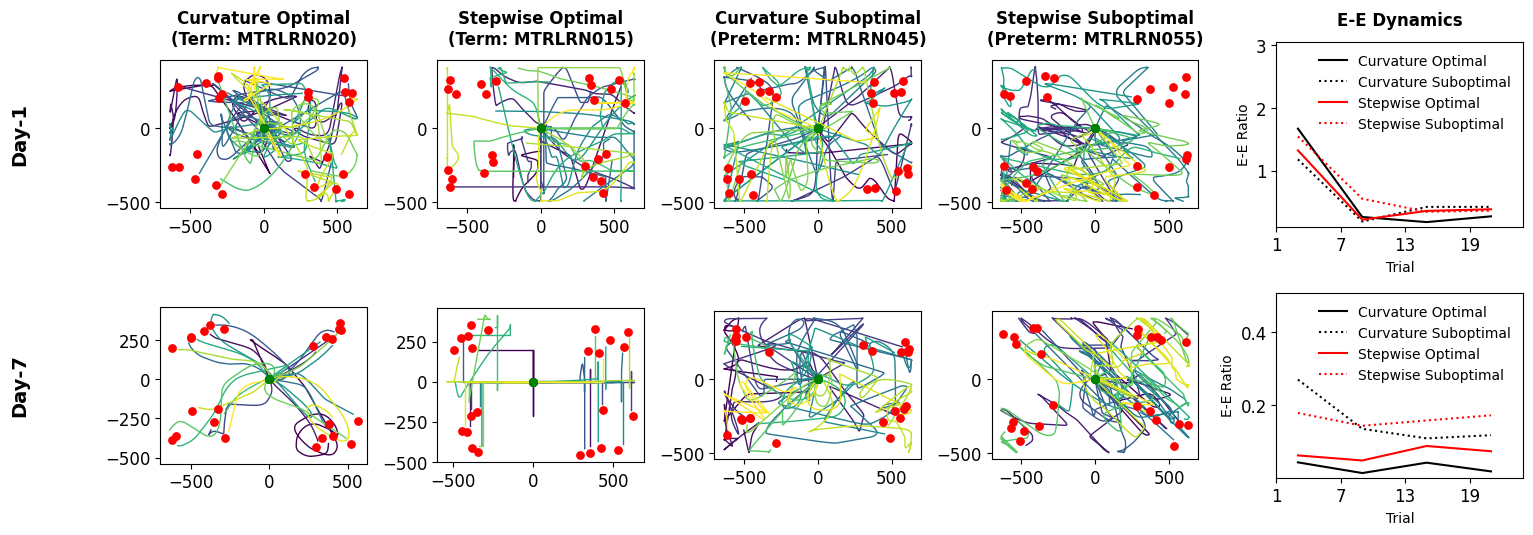

"\nPretem\n['MTRLRN002' 'MTRLRN013' 'MTRLRN029' 'MTRLRN030' 'MTRLRN031' 'MTRLRN038'\n 'MTRLRN039' 'MTRLRN043' 'MTRLRN044' 'MTRLRN045' 'MTRLRN048' 'MTRLRN055'\n 'MTRLRN056' 'MTRLRN058' 'MTRLRN060' 'MTRLRN062' 'MTRLRN064' 'MTRLRN065']\nTerm\n['MTRLRN004' 'MTRLRN005' 'MTRLRN007' 'MTRLRN008' 'MTRLRN009' 'MTRLRN010'\n 'MTRLRN011' 'MTRLRN012' 'MTRLRN014' 'MTRLRN015' 'MTRLRN016' 'MTRLRN017'\n 'MTRLRN019' 'MTRLRN020' 'MTRLRN021' 'MTRLRN022' 'MTRLRN025' 'MTRLRN026'\n 'MTRLRN027' 'MTRLRN032' 'MTRLRN033' 'MTRLRN035' 'MTRLRN036' 'MTRLRN037'\n 'MTRLRN040' 'MTRLRN041' 'MTRLRN042' 'MTRLRN046' 'MTRLRN047' 'MTRLRN049'\n 'MTRLRN050' 'MTRLRN051' 'MTRLRN052' 'MTRLRN053' 'MTRLRN054' 'MTRLRN057'\n 'MTRLRN066' 'MTRLRN067' 'MTRLRN068' 'MTRLRN069' 'MTRLRN070' 'MTRLRN071'\n 'MTRLRN072' 'MTRLRN073' 'MTRLRN074' 'MTRLRN075' 'MTRLRN076' 'MTRLRN077'\n 'MTRLRN078' 'MTRLRN079']\n"

In [60]:
# --- Case study: Curvature vs Stepwise strategy (2x5 figure) ---
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MICRO_COL = "exploration_exploitation_ratio"

def _find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def _parse_path(val):
    if isinstance(val, (list, tuple, np.ndarray)):
        arr = np.asarray(val)
    elif isinstance(val, str):
        try:
            arr = np.asarray(ast.literal_eval(val))
        except Exception:
            return None
    else:
        return None
    if arr.ndim == 1 and arr.size % 2 == 0:
        arr = arr.reshape(-1, 2)
    if arr.ndim >= 2 and arr.shape[1] >= 2:
        return arr[:, 0], arr[:, 1]
    return None

def _filter_subset(df, pid, session_no, task_type):
    session_col = _find_col(df, ["session_no", "session", "Session", "session_id"])
    task_col = _find_col(df, ["task_type", "task", "Task"])
    if session_col is None or task_col is None:
        return None
    sub = df.copy()
    sub = sub[sub["participant_id"].astype(str) == str(pid)]
    sub = sub[pd.to_numeric(sub[task_col], errors="coerce") == int(task_type)]
    sub = sub[pd.to_numeric(sub[session_col], errors="coerce") == int(session_no)]
    return sub

def _get_paths(df, pid, session_no, task_type):
    path_col = _find_col(df, ["path", "Path", "trajectory", "traj", "trajectory_path"])
    trial_col = _find_col(df, ["trial_seq", "trial", "trial_no", "Trial"])
    sx_col = _find_col(df, ["start_point_x"])
    sy_col = _find_col(df, ["start_point_y"])
    tx_col = _find_col(df, ["target_point_x"])
    ty_col = _find_col(df, ["target_point_y"])
    if path_col is None:
        return []
    sub = _filter_subset(df, pid, session_no, task_type)
    if sub is None or sub.empty:
        return []
    if trial_col is not None:
        sub[trial_col] = pd.to_numeric(sub[trial_col], errors="coerce")
        sub = sub.sort_values(trial_col)
    paths = []
    for _, row in sub.iterrows():
        parsed = _parse_path(row[path_col])
        if parsed is None:
            continue
        sx = sy = tx = ty = None
        if None not in (sx_col, sy_col, tx_col, ty_col):
            try:
                sx = float(row[sx_col])
                sy = float(row[sy_col])
                tx = float(row[tx_col])
                ty = float(row[ty_col])
            except Exception:
                sx = sy = tx = ty = None
        paths.append((parsed[0], parsed[1], sx, sy, tx, ty))
    return paths

def _get_ee_series(df, pid, session_no, task_type):
    session_col = _find_col(df, ["session_no", "session", "Session", "session_id"])
    trial_col = _find_col(df, ["trial_seq", "trial", "trial_no", "Trial"])
    task_col = _find_col(df, ["task_type", "task", "Task"])
    if session_col is None or trial_col is None or task_col is None:
        return None, None
    sub = df.copy()
    sub = sub[sub["participant_id"].astype(str) == str(pid)]
    sub = sub[pd.to_numeric(sub[task_col], errors="coerce") == int(task_type)]
    sub = sub[pd.to_numeric(sub[session_col], errors="coerce") == int(session_no)]
    sub[trial_col] = pd.to_numeric(sub[trial_col], errors="coerce")
    sub = sub.dropna(subset=[trial_col, MICRO_COL]).sort_values(trial_col)
    x = np.arange(1, len(sub) + 1)
    y = pd.to_numeric(sub[MICRO_COL], errors="coerce").values
    return x, y

def _bin_series(x, y, bin_size=3, max_trials=24):
    if x is None or y is None:
        return None, None
    x = np.asarray(x)
    y = np.asarray(y)
    mask = np.isfinite(x) & np.isfinite(y) & (x >= 1) & (x <= max_trials)
    if mask.sum() == 0:
        return None, None
    df = pd.DataFrame({"trial": x[mask], "y": y[mask]})
    df["bin"] = ((df["trial"] - 1) // bin_size) + 1
    n_bins = int(np.ceil(max_trials / bin_size))
    df = df[df["bin"].between(1, n_bins)]
    out = df.groupby("bin", as_index=False)["y"].mean()
    out["x"] = (out["bin"] - 0.5) * bin_size
    return out["x"].values, out["y"].values

def _plot_paths(ax, paths, max_traj=24):
    cmap = plt.cm.viridis
    if not paths:
        ax.text(0.5, 0.5, "No path found", ha="center", va="center")
        return
    n = min(len(paths), max_traj)
    colors = cmap(np.linspace(0, 1, n))
    for i in range(n):
        x, y, sx, sy, tx, ty = paths[i]
        ax.plot(x, y, color=colors[i], linewidth=1)
        if None not in (sx, sy, tx, ty):
            ax.scatter(sx, sy, color="green", s=28, zorder=3)
            ax.scatter(tx, ty, color="red", s=28, zorder=3)
    ax.set_aspect("equal", adjustable="box")

def _add_column_headers(fig, axes, labels, y_pad=0.02, fontsize=12):
    for j, label in enumerate(labels):
        pos = axes[0, j].get_position()
        x = (pos.x0 + pos.x1) / 2
        y = pos.y1 + y_pad
        fig.text(x, y, label, ha="center", va="bottom", fontsize=fontsize, fontweight="bold")

def _add_row_labels(fig, axes, labels, x=0.01, fontsize=12):
    for i, label in enumerate(labels):
        pos = axes[i, 0].get_position()
        y = (pos.y0 + pos.y1) / 2
        fig.text(x, y, label, ha="left", va="center", fontsize=fontsize, rotation=90, fontweight="bold")

def plot_strategy_case(pid_term_uni="MTRLRN070", pid_term_bi="MTRLRN015",
                       pid_preterm_uni="MTRLRN058", pid_preterm_bi="MTRLRN055",
                       day1_session=1, day7_session=5, bin_size=3):
    fig, axes = plt.subplots(
        2,
        5,
        figsize=(16, 6),
        gridspec_kw={"width_ratios": [1, 1, 1, 1, 1.5]},
    )

    def plot_ee_panel(ax, session_no):
        series = [
            (pid_term_uni, 0, "Curvature Optimal", "black", "-"),
            (pid_preterm_uni, 0, "Curvature Suboptimal", "black", ":"),
            (pid_term_bi, 1, "Stepwise Optimal", "red", "-"),
            (pid_preterm_bi, 1, "Stepwise Suboptimal", "red", ":"),
        ]
        any_plotted = False
        for pid, task_type, label, color, style in series:
            x, y = _get_ee_series(msl_df, pid, session_no, task_type=task_type)
            bx, by = _bin_series(x, y, bin_size=bin_size, max_trials=24)
            if bx is not None:
                ax.plot(bx, by, label=label, color=color, linestyle=style)
                any_plotted = True
        if not any_plotted:
            ax.text(0.5, 0.5, "No E-E data", ha="center", va="center")
        ax.set_xlabel("Trial")
        ax.set_ylabel("E-E Ratio")
        ax.set_xlim(1, 24)
        ax.set_xticks(np.arange(1, 25, bin_size))
        ax.set_box_aspect(0.75)
        ymin, ymax = ax.get_ylim()
        if np.isfinite(ymin) and np.isfinite(ymax) and ymax > ymin:
            ax.set_ylim(ymin, ymax + (ymax - ymin) * 0.8)
        ax.legend(frameon=False, fontsize=10, loc="upper right")

    # Row 1: Day-1
    _plot_paths(axes[0, 0], _get_paths(msl_df, pid_term_uni, day1_session, task_type=0))
    _plot_paths(axes[0, 1], _get_paths(msl_df, pid_term_bi, day1_session, task_type=1))
    _plot_paths(axes[0, 2], _get_paths(msl_df, pid_preterm_uni, day1_session, task_type=0))
    _plot_paths(axes[0, 3], _get_paths(msl_df, pid_preterm_bi, day1_session, task_type=1))
    plot_ee_panel(axes[0, 4], day1_session)

    # Row 2: Day-7
    _plot_paths(axes[1, 0], _get_paths(msl_df, pid_term_uni, day7_session, task_type=0))
    _plot_paths(axes[1, 1], _get_paths(msl_df, pid_term_bi, day7_session, task_type=1))
    _plot_paths(axes[1, 2], _get_paths(msl_df, pid_preterm_uni, day7_session, task_type=0))
    _plot_paths(axes[1, 3], _get_paths(msl_df, pid_preterm_bi, day7_session, task_type=1))
    plot_ee_panel(axes[1, 4], day7_session)

    col_headers = [
        f"Curvature Optimal\n(Term: {pid_term_uni})",
        f"Stepwise Optimal\n(Term: {pid_term_bi})",
        f"Curvature Suboptimal\n(Preterm: {pid_preterm_uni})",
        f"Stepwise Suboptimal\n(Preterm: {pid_preterm_bi})",
        "E-E Dynamics",
    ]

    for ax in axes.flatten():
        ax.tick_params(axis="both", labelsize=12)
        ax.grid(False)
    plt.tight_layout(rect=[0.06, 0.0, 1.0, 0.86])
    for i in range(2):
        pos = axes[i, 4].get_position()
        axes[i, 4].set_position([pos.x0 - 0.015, pos.y0, pos.width, pos.height])
    _add_column_headers(fig, axes, col_headers, y_pad=0.02, fontsize=12)
    _add_row_labels(fig, axes, ["Day-1", "Day-7"], x=0.01, fontsize=14)
    # Save to save_path directory
    if "save_path" in globals() and isinstance(save_path, str) and len(save_path.strip()) > 0:
        out_dir = Path(save_path)
    else:
        out_dir = Path(".")
    out_dir.mkdir(parents=True, exist_ok=True)

    out_png = out_dir / f"case_study.png"
    fig.savefig(out_png, dpi=600, bbox_inches="tight")
    print(f"Saved figure to: {out_png}")
    plt.show()

# Example usage:
plot_strategy_case(
    pid_term_uni="MTRLRN020",
    pid_term_bi="MTRLRN015",
    pid_preterm_uni="MTRLRN045",
    pid_preterm_bi="MTRLRN055", 
    day1_session=1,
    day7_session=5,
    bin_size=6,
 )

# plot_strategy_case(
#     pid_term_uni="MTRLRN017", ## 'MTRLRN004', "MTRLRN007", "MTRLRN017", "MTRLRN020","MTRLRN022", MTRLRN077
#     pid_term_bi="MTRLRN015", 
#     pid_preterm_uni="MTRLRN058", ## "MTRLRN045"
#     pid_preterm_bi="MTRLRN055", ## "MTRLRN008", "MTRLRN0010", "MTRLRN062", "MTRLRN025"
#     day1_session=1,
#     day7_session=5,
#     bin_size=6,
#  )
'''
Pretem
['MTRLRN002' 'MTRLRN013' 'MTRLRN029' 'MTRLRN030' 'MTRLRN031' 'MTRLRN038'
 'MTRLRN039' 'MTRLRN043' 'MTRLRN044' 'MTRLRN045' 'MTRLRN048' 'MTRLRN055'
 'MTRLRN056' 'MTRLRN058' 'MTRLRN060' 'MTRLRN062' 'MTRLRN064' 'MTRLRN065']
Term
['MTRLRN004' 'MTRLRN005' 'MTRLRN007' 'MTRLRN008' 'MTRLRN009' 'MTRLRN010'
 'MTRLRN011' 'MTRLRN012' 'MTRLRN014' 'MTRLRN015' 'MTRLRN016' 'MTRLRN017'
 'MTRLRN019' 'MTRLRN020' 'MTRLRN021' 'MTRLRN022' 'MTRLRN025' 'MTRLRN026'
 'MTRLRN027' 'MTRLRN032' 'MTRLRN033' 'MTRLRN035' 'MTRLRN036' 'MTRLRN037'
 'MTRLRN040' 'MTRLRN041' 'MTRLRN042' 'MTRLRN046' 'MTRLRN047' 'MTRLRN049'
 'MTRLRN050' 'MTRLRN051' 'MTRLRN052' 'MTRLRN053' 'MTRLRN054' 'MTRLRN057'
 'MTRLRN066' 'MTRLRN067' 'MTRLRN068' 'MTRLRN069' 'MTRLRN070' 'MTRLRN071'
 'MTRLRN072' 'MTRLRN073' 'MTRLRN074' 'MTRLRN075' 'MTRLRN076' 'MTRLRN077'
 'MTRLRN078' 'MTRLRN079']
'''



In [61]:
# --- Case-study summary table (means for D1 and D7) ---
import numpy as np
import pandas as pd

def _find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def _normalize_scalar(val, fallback=np.nan):
    if isinstance(val, (list, tuple, np.ndarray)) and len(val) > 0:
        val = val[0]
    try:
        return int(val)
    except Exception:
        try:
            return float(val)
        except Exception:
            return fallback

def _subset_case(df, pid, session_no, task_type):
    session_col = _find_col(df, ["session_no", "session", "Session", "session_id"])
    task_col = _find_col(df, ["task_type", "task", "Task"])
    if session_col is None or task_col is None:
        return df.iloc[0:0].copy()
    task_type = _normalize_scalar(task_type)
    session_no = _normalize_scalar(session_no)
    sub = df.copy()
    sub = sub[sub["participant_id"].astype(str) == str(pid)]
    sub = sub[pd.to_numeric(sub[task_col], errors="coerce") == task_type]
    sub = sub[pd.to_numeric(sub[session_col], errors="coerce") == session_no]
    return sub

def _mean_or_nan(series):
    vals = pd.to_numeric(pd.Series(series), errors="coerce").dropna().astype(float)
    return float(vals.mean()) if len(vals) > 0 else np.nan

def _success_pct(series):
    vals = pd.to_numeric(pd.Series(series), errors="coerce").dropna().astype(float)
    if len(vals) == 0:
        return np.nan
    return float(vals.mean() * 100.0)

# Update these to match your case-study participants
pid_term_uni = "MTRLRN010"
pid_term_bi = "MTRLRN015"
pid_preterm_uni = "MTRLRN045"
pid_preterm_bi = "MTRLRN055"
# pid_term_uni="MTRLRN020",
# pid_term_bi="MTRLRN015",
# pid_preterm_uni="MTRLRN045",
# pid_preterm_bi="MTRLRN055", 
day1_session = 1
day7_session = 5

rows = [
    ("Curvature Optimal (Term)", pid_term_uni, 0),
    ("Stepwise Optimal (Term)", pid_term_bi, 1),
    ("Curvature Suboptimal (Preterm)", pid_preterm_uni, 0),
    ("Stepwise Suboptimal (Preterm)", pid_preterm_bi, 1),
]

out_rows = []
for row in rows:
    if len(row) < 3:
        continue
    label, pid, task_type = row[0], row[1], row[2]
    d1 = _subset_case(msl_df, pid, day1_session, task_type)
    d7 = _subset_case(msl_df, pid, day7_session, task_type)
    out_rows.append({
        "Strategy": label,
        "E-E D1": _mean_or_nan(d1.get(MICRO_COL, [])),
        "E-E D7": _mean_or_nan(d7.get(MICRO_COL, [])),
        "Success D1 (%)": _success_pct(d1.get("is_success", [])),
        "Success D7 (%)": _success_pct(d7.get("is_success", [])),
        "Time D1 (s)": _mean_or_nan(d1.get("completion_time", [])),
        "Time D7 (s)": _mean_or_nan(d7.get("completion_time", [])),
        "RMSD D1": _mean_or_nan(d1.get("rmsd", [])),
        "RMSD D7": _mean_or_nan(d7.get("rmsd", [])),
    })

summary_df = pd.DataFrame(out_rows)
summary_df = summary_df.round(4)
summary_df

,Strategy,E-E D1,E-E D7,Success D1 (%),Success D7 (%),Time D1 (s),Time D7 (s),RMSD D1,RMSD D7
0,Curvature Optimal (Term),0.5945,0.0610,20.8333,70.8333,9.9532,8.3903,215.1283,134.9059
1,Stepwise Optimal (Term),0.5718,0.0681,20.8333,100.0000,10.1939,5.0968,270.9083,152.8541
2,Curvature Suboptimal (Preterm),0.5543,0.1579,8.3333,91.6667,10.7525,5.4528,311.4282,165.1266
3,Stepwise Suboptimal (Preterm),0.7022,0.1630,25.0000,79.1667,9.9853,5.9937,321.6761,148.3152
